# Segmentation

A segmenter splits an image into masks, one per object or region. Masks clean up patch
features: averaging the features inside each mask gives one clear feature per object. This page
runs MobileSAM on one frame, pools Talk2DINO features in its masks, and shows the sky mask the
mesh stage uses.

In [1]:
import contextlib
import io

import matplotlib.pyplot as plt
import numpy as np
import transformers
from PIL import Image

from collab_splats.semantics import (
    MobileSAMSegmentation,
    Talk2DinoExtractor,
    aggregate_masked_features,
    sky_masks,
)
from collab_splats.utils.image import open_image, resize_image
from collab_splats.utils.visualization import overlay_masks, pca_to_rgb

%run ../tutorial.py

# Hide a harmless checkpoint warning from Talk2DINO
transformers.logging.set_verbosity_error()

# Image panels without axes
BARE = {"frame_on": False, "xticks": [], "yticks": []}

# One frame at 1024 px
image = open_image(QUERY_IMAGE)
frame = np.asarray(resize_image(image, 1024).convert("RGB"))

## 1. Two ways to prompt SAM

- `object`: a detector finds objects, then SAM draws one mask per object, down to small litter.
- `auto`: SAM is prompted with a grid of points, so it also masks large regions like the ground.

Segment the frame both ways:

object: 53 masks


auto: 39 masks


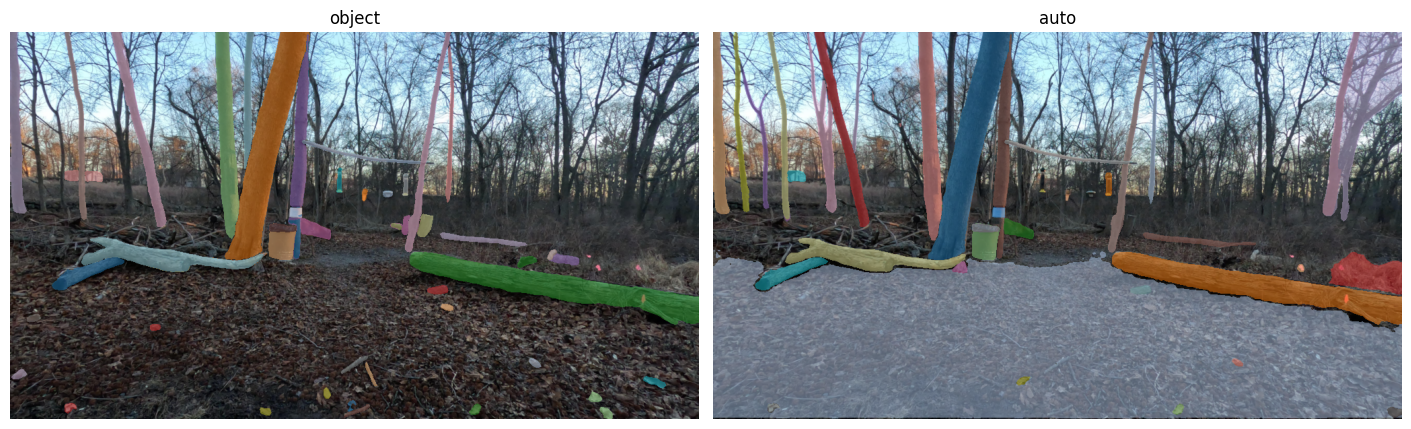

In [2]:
masks = {}

for strategy in ("object", "auto"):
    # Hide model-loading output
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        segmenter = MobileSAMSegmentation(strategy=strategy, device="cuda")
        masks[strategy], _ = segmenter.segment(frame)

    print(f"{strategy}: {len(masks[strategy])} masks")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw=BARE, layout="constrained")

for ax, strategy in zip(axes, masks):
    ax.imshow(overlay_masks(frame, masks[strategy]))
    ax.set_title(strategy)

Each color is one mask. `object` covers trunks, logs and small items but not the ground; `auto`
also covers the ground. Neither masks the sky.

## 2. Pooling features per mask

`aggregate_masked_features` averages the features inside each mask and paints the average back
over the mask. Where masks overlap, the later one wins; pixels in no mask get zero.

Pool Talk2DINO features in the `object` masks:

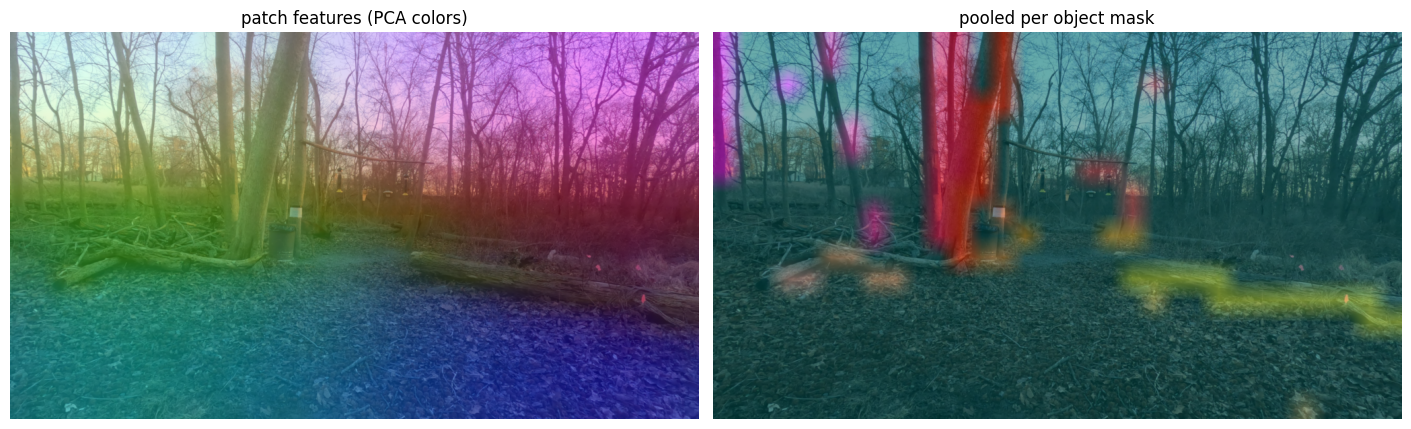

In [3]:
features = Talk2DinoExtractor().forward([frame])[0]
patch_grid = tuple(features.shape[1:])
pooled = aggregate_masked_features(
    features, masks["object"], resolution=patch_grid, final_resolution=patch_grid
)

panels = {"patch features (PCA colors)": features, "pooled per object mask": pooled}
fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw=BARE, layout="constrained")

for ax, (title, fmap) in zip(axes, panels.items()):
    ax.imshow(pca_to_rgb(fmap, frame))
    ax.set_title(title)

Similar colors mean similar features. On the left, colors vary patch by patch within an object;
on the right, each object is one flat color.

## 3. Sky masks

The mesh stage removes sky before fusing depth (`mesh.mask_sky`). `sky_masks` gives each pixel a
sky probability and keeps pixels above 0.5. It reads a folder of keyframes, so the frame is saved
into one first.

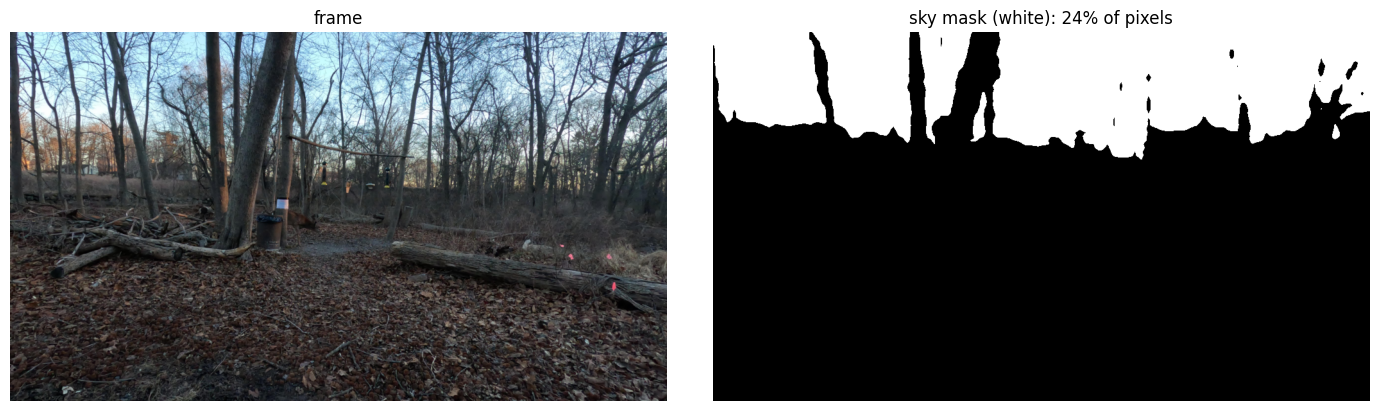

In [4]:
sky_dir = work_dir("segmentation")
frame_store = sky_dir / "frames"
frame_store.mkdir(exist_ok=True)
Image.fromarray(frame).save(frame_store / "frame_000000.png")
sky = sky_masks(frame_store, cache_dir=sky_dir / "sky")[0]

panels = {"frame": frame, f"sky mask (white): {sky.mean():.0%} of pixels": sky}
fig, axes = plt.subplots(1, 2, figsize=(14, 4), subplot_kw=BARE, layout="constrained")

for ax, (title, panel) in zip(axes, panels.items()):
    ax.imshow(panel, cmap="gray")
    ax.set_title(title)

White pixels are sky; the mesh stage drops their depth so the sky does not become a backdrop.

## In a pipeline run

The pipeline uses segmentation in the mesh stage, to remove the sky:

```yaml
mesh:
  mask_sky: true
```